# Walk-forward (rolling-origin) quantile harness — 0DTE SPY

Configurable walk-forward validation for predicting **quantiles of the end-of-day close**,
trained on the already-normalized target `log_return_norm = log_return / norm_factor`.

**Correctness invariants enforced below**
- All splitting is at the **trading-day level** (`expiration`), days are atomic — never split a day across train/val/test.
- Validation = the **most-recent `val_days` inside the window**, temporally *after* training. Test = the days **immediately after** the window. No shuffling across time.
- Any extra scaling is fit on the **train portion only**.
- `expiration`, `underlying_price`, `norm_factor`, and the target are **never** fed as features.
- Warm-up: no test fold is emitted until `train_window_days` of history exist.

> The test folds must **never** be used to pick hyperparameters. A separate, clearly-labeled
> `train_window_days` sweep at the bottom selects on **validation** only.

In [1]:
from __future__ import annotations

import os
import random
import warnings
from dataclasses import dataclass, field, replace
from typing import Protocol, Sequence

import numpy as np
import pandas as pd
import lightgbm as lgb

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# LightGBM is fed numpy arrays; silence sklearn's benign feature-name mismatch warning.
warnings.filterwarnings("ignore", message="X does not have valid feature names")


def set_seed(seed: int) -> None:
    """Seed all RNGs used in this notebook for determinism."""
    random.seed(seed)
    np.random.seed(seed)


def _resolve(path: str) -> str:
    """Resolve a repo-relative path whether cwd is the repo root or notebooks/."""
    for base in (".", "..", os.path.dirname(os.getcwd())):
        candidate = os.path.join(base, path)
        if os.path.exists(candidate):
            return candidate
    return path

In [2]:
DEFAULT_FEATURES: tuple[str, ...] = (
    "net_gex_norm", "net_dex_norm", "net_tex_norm",
    "atm_iv", "iv_call_25d", "iv_put_25d", "iv_skew_25d", "iv_smile_curvature_25d",
    "ttm_min", "theta_decay", "log_return_from_open",
    "oi_concentration_top3", "put_oi_fraction", "atm_spread_norm",
    "distance_to_max_oi_norm", "put_max_oi_strike_norm", "call_max_oi_strike_norm",
)


def _default_lgbm_params() -> dict:
    """LightGBM quantile defaults. NaNs are handled natively; deterministic for repro."""
    return {
        "n_estimators": 2000,
        "learning_rate": 0.03,
        "num_leaves": 15,
        "min_child_samples": 100,
        "subsample": 0.8,
        "subsample_freq": 1,
        "colsample_bytree": 0.8,
        "reg_lambda": 1.0,
        "verbosity": -1,
        "deterministic": True,
        "force_row_wise": True,
    }


@dataclass
class Config:
    """All methodological knobs for one walk-forward experiment.

    Window semantics ("val inside window"): the window is `train_window_days` long;
    the model fits on the first `train_window_days - val_days` days and validates on the
    most-recent `val_days` days of that window (temporally after the fit days). The test
    block is the `test_days` days immediately following the window.
    """

    # data
    data_path: str = "data/model_input/SPY.parquet"
    feature_cols: tuple[str, ...] = DEFAULT_FEATURES
    target_col: str = "log_return_norm"
    group_col: str = "expiration"          # trading-day key (0DTE -> expiration == trade date)
    norm_factor_col: str = "norm_factor"
    underlying_col: str = "underlying_price"

    # output distribution
    quantiles: tuple[float, ...] = (0.1, 0.25, 0.5, 0.75, 0.9)

    # walk-forward
    window_mode: str = "rolling"           # "rolling" | "expanding"
    train_window_days: int = 40            # total days in the window (fit + val)
    val_days: int = 8                      # most-recent days of the window, held out for val
    test_days: int = 1                     # days per test fold
    stride_days: int = 1                   # step between successive test origins

    # preprocessing (features are already normalized; this is optional extra scaling)
    extra_scaling: str = "none"            # "standardize" | "none" — fit on TRAIN only

    # date subset for fast iteration (ISO "YYYY-MM-DD", inclusive)
    start_date: str | None = None
    end_date: str | None = None

    # reproducibility
    seed: int = 42

    # model
    early_stopping_rounds: int = 50
    model_params: dict = field(default_factory=_default_lgbm_params)

    def __post_init__(self) -> None:
        assert self.window_mode in ("rolling", "expanding"), self.window_mode
        assert self.extra_scaling in ("standardize", "none"), self.extra_scaling
        assert 0 < self.val_days < self.train_window_days, \
            "need 0 < val_days < train_window_days (val is carved from the window)"
        assert self.test_days >= 1 and self.stride_days >= 1
        assert all(0.0 < q < 1.0 for q in self.quantiles)
        assert list(self.quantiles) == sorted(self.quantiles), "quantiles must be ascending"
        leaked = [c for c in self.feature_cols
                  if c in {self.group_col, self.underlying_col, self.norm_factor_col, self.target_col}]
        assert not leaked, f"metadata/target leaked into feature_cols: {leaked}"

## CLI overrides (optional)

`parse_overrides()` lets the same harness be driven from a shell when this notebook is
exported to a script (`jupyter nbconvert --to script`). In the notebook it is a no-op
because Jupyter's own args are ignored via `parse_known_args`.

In [3]:
import argparse


def parse_overrides(base: Config | None = None) -> Config:
    """Apply --knob overrides on top of a base Config. Safe to call inside Jupyter."""
    base = base or Config()
    p = argparse.ArgumentParser(description="Walk-forward quantile harness")
    p.add_argument("--data-path", type=str)
    p.add_argument("--window-mode", choices=["rolling", "expanding"])
    p.add_argument("--train-window-days", type=int)
    p.add_argument("--val-days", type=int)
    p.add_argument("--test-days", type=int)
    p.add_argument("--stride-days", type=int)
    p.add_argument("--extra-scaling", choices=["standardize", "none"])
    p.add_argument("--start-date", type=str)
    p.add_argument("--end-date", type=str)
    p.add_argument("--seed", type=int)
    p.add_argument("--quantiles", type=float, nargs="+")
    args, _ = p.parse_known_args()
    overrides = {k: v for k, v in vars(args).items() if v is not None}
    if "quantiles" in overrides:
        overrides["quantiles"] = tuple(overrides["quantiles"])
    return replace(base, **overrides)

## Load data + validate column groups

Prints schema/head and asserts the three groups are disjoint and complete.

In [4]:
def load_dataset(cfg: Config) -> pd.DataFrame:
    """Load the model-input parquet, validate column groups, apply optional date subset."""
    df = pd.read_parquet(_resolve(cfg.data_path))

    missing = [c for c in cfg.feature_cols if c not in df.columns]
    assert not missing, f"feature_cols missing from data: {missing}"
    for col in (cfg.group_col, cfg.target_col, cfg.norm_factor_col, cfg.underlying_col):
        assert col in df.columns, f"required column missing: {col}"
    assert (df[cfg.norm_factor_col] > 0).all(), "norm_factor must be > 0 to de-normalize"

    df = df.sort_values([cfg.group_col, "timestamp"]).reset_index(drop=True)
    # group_col holds datetime.date objects; coerce ISO-string bounds to match.
    if cfg.start_date is not None:
        df = df[df[cfg.group_col] >= pd.Timestamp(cfg.start_date).date()]
    if cfg.end_date is not None:
        df = df[df[cfg.group_col] <= pd.Timestamp(cfg.end_date).date()]
    return df.reset_index(drop=True)


_cfg_preview = Config()
_df_preview = load_dataset(_cfg_preview)

print("shape:", _df_preview.shape)
print("dtypes:")
print(_df_preview.dtypes)
print()
_meta = [_cfg_preview.group_col, "timestamp", _cfg_preview.underlying_col, _cfg_preview.norm_factor_col]
print("FEATURES (fed to model):", list(_cfg_preview.feature_cols))
print("METADATA  (kept, never features):", _meta)
print("TARGET    :", _cfg_preview.target_col)
print()
_days = sorted(_df_preview[_cfg_preview.group_col].unique())
print(f"{len(_days)} trading days: {_days[0]} -> {_days[-1]}")
print("rows per day:", _df_preview.groupby(_cfg_preview.group_col).size().agg(["min", "median", "max"]).to_dict())
_df_preview.head(3).T

shape: (23299, 22)
dtypes:
expiration                                           object
timestamp                  datetime64[us, America/New_York]
underlying_price                                    float64
net_gex_norm                                        float64
net_dex_norm                                        float64
atm_iv                                              float64
iv_call_25d                                         float64
iv_put_25d                                          float64
iv_skew_25d                                         float64
iv_smile_curvature_25d                              float64
net_tex_norm                                        float64
ttm_min                                             float64
theta_decay                                         float64
log_return_from_open                                float64
oi_concentration_top3                               float64
put_oi_fraction                                     float64
atm_spread_no

,0,1,2
expiration,2022-08-03,2022-08-03,2022-08-03
timestamp,2022-08-03 09:45:00-04:00,2022-08-03 10:00:00-04:00,2022-08-03 10:15:00-04:00
underlying_price,410.9,411.52,412.15
net_gex_norm,755143.743022,1381179.044474,2020734.265384
net_dex_norm,-2048538.68,-4420136.23,-4668179.41
atm_iv,0.34125,0.32735,0.3
iv_call_25d,0.3364,0.3198,0.2851
iv_put_25d,0.3579,0.3374,0.3164
iv_skew_25d,0.0215,0.0176,0.0313
iv_smile_curvature_25d,0.0118,0.0025,0.0015


## Fold generation (day-level, temporal)

For each test origin `s` (index into the sorted unique days):
- **val**  = `days[s - val_days : s]` (most recent `val_days` before test)
- **train** = `days[s - train_window_days : s - val_days]` (rolling) or `days[0 : s - val_days]` (expanding)
- **test** = `days[s : s + test_days]`

The first origin is `s = train_window_days` (warm-up), then stride by `stride_days`.

In [5]:
@dataclass
class Fold:
    idx: int
    train_days: list
    val_days: list
    test_days: list


def generate_folds(days: Sequence, cfg: Config) -> list[Fold]:
    """Build the ordered list of walk-forward folds. Days must be sorted & unique."""
    days = list(days)
    n = len(days)
    folds: list[Fold] = []
    s = cfg.train_window_days  # warm-up: full window of history must precede the first test
    idx = 0
    while s + cfg.test_days <= n:
        val_block = days[s - cfg.val_days:s]
        if cfg.window_mode == "rolling":
            train_block = days[s - cfg.train_window_days:s - cfg.val_days]
        else:  # expanding
            train_block = days[0:s - cfg.val_days]
        test_block = days[s:s + cfg.test_days]
        # invariants: strictly increasing, disjoint, atomic days
        assert max(train_block) < min(val_block) < min(test_block)
        assert not (set(train_block) & set(val_block) & set(test_block))
        folds.append(Fold(idx, train_block, val_block, test_block))
        idx += 1
        s += cfg.stride_days
    return folds


# sanity preview
_folds_preview = generate_folds(_days, _cfg_preview)
print(f"{len(_folds_preview)} folds")
_f0, _fL = _folds_preview[0], _folds_preview[-1]
for _f in (_f0, _fL):
    print(f"fold {_f.idx:>3}: train {_f.train_days[0]}..{_f.train_days[-1]} "
          f"({len(_f.train_days)}d) | val {_f.val_days[0]}..{_f.val_days[-1]} "
          f"({len(_f.val_days)}d) | test {_f.test_days[0]}..{_f.test_days[-1]} ({len(_f.test_days)}d)")

892 folds
fold   0: train 2022-08-03..2022-10-14 (32d) | val 2022-10-17..2022-11-02 (8d) | test 2022-11-04..2022-11-04 (1d)
fold 891: train 2026-04-02..2026-05-18 (32d) | val 2026-05-19..2026-05-29 (8d) | test 2026-06-01..2026-06-01 (1d)


## Feature matrix + optional standardizer

`build_xy` selects only `feature_cols` (metadata/target never enter `X`). The standardizer
is **fit on train only** and reused for val/test; it is nan-safe and leaves NaNs as NaNs so
LightGBM keeps handling them natively.

In [6]:
def build_xy(df: pd.DataFrame, days: Sequence, cfg: Config):
    """Return (X, y, frame) for the rows whose group_col is in `days`."""
    sub = df[df[cfg.group_col].isin(days)]
    X = sub[list(cfg.feature_cols)].to_numpy(dtype=float)
    y = sub[cfg.target_col].to_numpy(dtype=float)
    return X, y, sub


class Standardizer:
    """Nan-safe standardizer. Fit on TRAIN only; NaNs pass through unchanged."""

    def __init__(self) -> None:
        self.mean_: np.ndarray | None = None
        self.std_: np.ndarray | None = None

    def fit(self, X: np.ndarray) -> "Standardizer":
        self.mean_ = np.nanmean(X, axis=0)
        std = np.nanstd(X, axis=0)
        std[std == 0] = 1.0
        self.std_ = std
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        return (X - self.mean_) / self.std_


def make_scaler(cfg: Config, X_train: np.ndarray) -> Standardizer | None:
    """Fit a scaler on train features, or None when extra_scaling == 'none'."""
    if cfg.extra_scaling == "standardize":
        return Standardizer().fit(X_train)
    return None

## Model interface + LightGBM quantile baseline

One LightGBM regressor per quantile (`objective="quantile"`, `alpha=q`), early-stopped on the
validation set. `predict_quantiles` **sorts** the per-row predictions to prevent quantile
crossing. Swap in a neural quantile model later by implementing the same two methods.

In [7]:
class QuantileModel(Protocol):
    """Pluggable quantile model contract."""

    def fit(self, X_train, y_train, X_val, y_val) -> "QuantileModel": ...
    def predict_quantiles(self, X) -> np.ndarray: ...  # shape [n_rows, n_quantiles]


class LGBMQuantileModel:
    """Independent LightGBM quantile regressors, one per quantile level."""

    def __init__(self, cfg: Config) -> None:
        self.quantiles = list(cfg.quantiles)
        self.params = dict(cfg.model_params)
        self.seed = cfg.seed
        self.early_stopping_rounds = cfg.early_stopping_rounds
        self.models_: dict[float, lgb.LGBMRegressor] = {}

    def fit(self, X_train, y_train, X_val, y_val) -> "LGBMQuantileModel":
        for q in self.quantiles:
            model = lgb.LGBMRegressor(
                objective="quantile", alpha=q, random_state=self.seed, **self.params
            )
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                callbacks=[lgb.early_stopping(self.early_stopping_rounds, verbose=False),
                           lgb.log_evaluation(0)],
            )
            self.models_[q] = model
        return self

    def predict_quantiles(self, X) -> np.ndarray:
        preds = np.column_stack([self.models_[q].predict(X) for q in self.quantiles])
        preds.sort(axis=1)  # enforce monotonicity: no quantile crossing
        return preds

## Metrics

- **Pinball loss** per quantile + mean, in **normalized** space (the training objective) and
  **de-normalized log-return** space (`pred * norm_factor` vs realized `log_return`).
- **Coverage** per quantile = fraction of realized targets at or below each predicted quantile
  (identical in both spaces since `norm_factor > 0`).

In [8]:
def pinball_loss(y_true: np.ndarray, preds: np.ndarray, quantiles: Sequence[float]):
    """Per-quantile pinball loss and its mean. preds shape [n, n_q]."""
    per_q = np.empty(len(quantiles))
    for j, q in enumerate(quantiles):
        d = y_true - preds[:, j]
        per_q[j] = np.mean(np.maximum(q * d, (q - 1.0) * d))
    return per_q, float(per_q.mean())


def coverage(y_true: np.ndarray, preds: np.ndarray, quantiles: Sequence[float]) -> np.ndarray:
    """Fraction of realized targets <= each predicted quantile (should approx the level)."""
    return np.array([(y_true <= preds[:, j]).mean() for j in range(len(quantiles))])

## `run_walk_forward`

Refits per fold exactly as the live model would (train → early-stop on val → predict test),
then **pools all test rows across every fold** for the aggregate metrics. The number of
independent **test days** is reported alongside — headline metrics are never from one day.

In [9]:
def run_walk_forward(cfg: Config, verbose: bool = True) -> dict:
    """Run the full walk-forward and return per-fold + aggregated results."""
    set_seed(cfg.seed)
    df = load_dataset(cfg)
    days = sorted(df[cfg.group_col].unique())
    folds = generate_folds(days, cfg)
    assert folds, "no folds emitted — not enough history for train_window_days + test_days"

    q = list(cfg.quantiles)
    fold_rows: list[dict] = []
    pred_frames: list[pd.DataFrame] = []
    pool_y_norm, pool_pred_norm, pool_nf = [], [], []

    for fold in folds:
        X_tr, y_tr, _ = build_xy(df, fold.train_days, cfg)
        X_va, y_va, _ = build_xy(df, fold.val_days, cfg)
        X_te, y_te, te = build_xy(df, fold.test_days, cfg)

        scaler = make_scaler(cfg, X_tr)
        if scaler is not None:
            X_tr, X_va, X_te = scaler.transform(X_tr), scaler.transform(X_va), scaler.transform(X_te)

        model = LGBMQuantileModel(cfg).fit(X_tr, y_tr, X_va, y_va)
        pred_norm = model.predict_quantiles(X_te)            # normalized space
        nf = te[cfg.norm_factor_col].to_numpy()
        pred_lr = pred_norm * nf[:, None]                    # de-normalized log-return space
        y_lr = y_te * nf                                     # realized log-return

        pool_y_norm.append(y_te); pool_pred_norm.append(pred_norm); pool_nf.append(nf)

        pl_norm, pl_norm_m = pinball_loss(y_te, pred_norm, q)
        pl_lr, pl_lr_m = pinball_loss(y_lr, pred_lr, q)
        cov = coverage(y_te, pred_norm, q)
        fold_rows.append({
            "fold": fold.idx,
            "test_day": f"{fold.test_days[0]}..{fold.test_days[-1]}",
            "n_test_rows": len(y_te),
            "pinball_norm": pl_norm_m,
            "pinball_lr": pl_lr_m,
            **{f"cov@{ql}": cov[j] for j, ql in enumerate(q)},
        })

        rec = te[[cfg.group_col, "timestamp", cfg.norm_factor_col]].copy()
        rec["realized_norm"] = y_te
        rec["realized_log_return"] = y_lr
        for j, ql in enumerate(q):
            rec[f"q{ql}_norm"] = pred_norm[:, j]
            rec[f"q{ql}_lr"] = pred_lr[:, j]
        pred_frames.append(rec)

    # ── aggregate across ALL pooled test rows (spanning many test days)
    Y = np.concatenate(pool_y_norm)
    P = np.vstack(pool_pred_norm)
    NF = np.concatenate(pool_nf)
    agg_pl_norm, agg_pl_norm_m = pinball_loss(Y, P, q)
    agg_pl_lr, agg_pl_lr_m = pinball_loss(Y * NF, P * NF[:, None], q)
    agg_cov = coverage(Y, P, q)

    test_days_used = sorted({d for f in folds for d in f.test_days})
    summary = pd.DataFrame({
        "quantile": q,
        "pinball_norm": agg_pl_norm,
        "pinball_lr": agg_pl_lr,
        "coverage": agg_cov,
        "coverage_error": agg_cov - np.array(q),
    })

    if verbose:
        print(f"folds: {len(folds)} | unique test days: {len(test_days_used)} "
              f"| pooled test rows: {len(Y)}")
        print(f"mean pinball  norm={agg_pl_norm_m:.5f}  log-return={agg_pl_lr_m:.6e}")

    return {
        "config": cfg,
        "folds": pd.DataFrame(fold_rows),
        "summary": summary,
        "predictions": pd.concat(pred_frames, ignore_index=True),
        "mean_pinball_norm": agg_pl_norm_m,
        "mean_pinball_lr": agg_pl_lr_m,
        "n_test_days": len(test_days_used),
    }

## Run — main knobs

Edit these flags to run an experiment. (Equivalent CLI flags exist via `parse_overrides`.)

In [10]:
cfg = Config(
    # --- main knobs ---
    window_mode="rolling",        # "rolling" | "expanding"
    train_window_days=30,         # total days in the window (fit + val)
    val_days=1,                   # most-recent days of the window held out for validation
    test_days=1,                  # days per test fold
    stride_days=1,                # step between test origins
    quantiles=(0.1, 0.25, 0.5, 0.75, 0.9),
    extra_scaling="none",         # "standardize" | "none"
    # --- fast iteration: uncomment to subset dates ---
    start_date="2026-03-31",
    end_date="2026-06-01",
    seed=42,
)
# cfg = parse_overrides(cfg)   # uncomment when running as a script

results = run_walk_forward(cfg)

folds: 13 | unique test days: 13 | pooled test rows: 325
mean pinball  norm=0.21056  log-return=6.844329e-04


## Summary table — aggregated pinball (both spaces) + coverage per quantile

In [11]:
print(f"window_mode={cfg.window_mode}  train_window_days={cfg.train_window_days}  "
      f"val_days={cfg.val_days}  test_days={cfg.test_days}  stride={cfg.stride_days}  "
      f"scaling={cfg.extra_scaling}")
print(f"aggregated over {results['n_test_days']} test days "
      f"({len(results['predictions'])} snapshot rows)\n")

_summary = results["summary"].copy()
_summary["coverage"] = _summary["coverage"].round(3)
_summary["coverage_error"] = _summary["coverage_error"].round(3)
print("Per-quantile (coverage_error = empirical - nominal; ~0 is well-calibrated):")
display(_summary.style.format({
    "pinball_norm": "{:.5f}", "pinball_lr": "{:.3e}",
    "coverage": "{:.3f}", "coverage_error": "{:+.3f}",
}))
print(f"\nMean pinball  ->  normalized: {results['mean_pinball_norm']:.5f}   "
      f"log-return: {results['mean_pinball_lr']:.3e}")

window_mode=rolling  train_window_days=30  val_days=1  test_days=1  stride=1  scaling=none
aggregated over 13 test days (325 snapshot rows)

Per-quantile (coverage_error = empirical - nominal; ~0 is well-calibrated):


,quantile,pinball_norm,pinball_lr,coverage,coverage_error
0,0.100000,0.15062,4.792e-04,0.160,+0.060
1,0.250000,0.25205,7.977e-04,0.280,+0.030
2,0.500000,0.28511,9.218e-04,0.538,+0.038
3,0.750000,0.23558,7.910e-04,0.788,+0.038
4,0.900000,0.12946,4.324e-04,0.926,+0.026



Mean pinball  ->  normalized: 0.21056   log-return: 6.844e-04


## Black–Scholes baseline (closed-form, parameter-free)

A sanity-check baseline: assume the EOD log-return follows geometric Brownian motion, so
`log_return ~ Normal(mu*T - 0.5*sigma²*T, sigma*sqrt(T))`. Since the data's `norm_factor`
already equals `sigma*sqrt(T)`, the **normalized** target is `Normal(mean, 1)` with
`mean = mu*T/norm_factor - 0.5*norm_factor`, and the q-th quantile is simply
`mean + Φ⁻¹(q)`. No fitting and no features — only a fixed annual drift `mu` (0.04, matching
`10_train_v1`).

`run_bs_baseline` walks the **same folds** as `run_walk_forward` and scores the BS quantiles on
the **identical pooled test rows**, so the comparison below is apples-to-apples. A useful model
must beat this baseline on pinball loss.

In [12]:
from scipy.stats import norm as _norm

BS_MU = 0.04                       # assumed annual drift (matches 10_train_v1)
BS_TTM_COL = "ttm_min"             # time-to-maturity in minutes, in the data frame
MIN_PER_YEAR = 365 * 1440         # calendar-minute year (matches 10_train_v1)


def bs_predict_quantiles(frame: pd.DataFrame, cfg: Config) -> np.ndarray:
    """Closed-form Black-Scholes (GBM) quantiles in NORMALIZED target space.

    Under GBM the EOD log-return ~ Normal(mu*T - 0.5*sigma**2*T, sigma*sqrt(T)).
    The data's norm_factor == sigma*sqrt(T), so the normalized target
    log_return_norm = log_return / norm_factor is Normal(mean, 1) with
        mean = mu*T / norm_factor - 0.5 * norm_factor
    (using sigma**2 * T == norm_factor**2). The q-th quantile is mean + Phi^{-1}(q).
    Parameter-free apart from the fixed drift mu -> no fitting, no train/val data.
    Returns shape [n_rows, n_quantiles].
    """
    ttm_years = frame[BS_TTM_COL].to_numpy(dtype=float) / MIN_PER_YEAR
    nf = frame[cfg.norm_factor_col].to_numpy(dtype=float)
    mean = BS_MU * ttm_years / nf - 0.5 * nf
    z = _norm.ppf(np.array(cfg.quantiles))
    return mean[:, None] + z[None, :]


def run_bs_baseline(cfg: Config, verbose: bool = True) -> dict:
    """Evaluate the BS baseline on EXACTLY the walk-forward test rows the model sees.

    Reuses the same fold generation as run_walk_forward but skips fitting: BS
    quantiles are closed-form per test row. Returns the same summary structure so
    the two are directly comparable.
    """
    df = load_dataset(cfg)
    days = sorted(df[cfg.group_col].unique())
    folds = generate_folds(days, cfg)
    assert folds, "no folds emitted — not enough history for train_window_days + test_days"

    q = list(cfg.quantiles)
    pool_y, pool_pred, pool_nf = [], [], []
    for fold in folds:
        _, y_te, te = build_xy(df, fold.test_days, cfg)
        pool_y.append(y_te)
        pool_pred.append(bs_predict_quantiles(te, cfg))   # normalized space
        pool_nf.append(te[cfg.norm_factor_col].to_numpy())

    Y = np.concatenate(pool_y)
    P = np.vstack(pool_pred)
    NF = np.concatenate(pool_nf)
    agg_pl_norm, agg_pl_norm_m = pinball_loss(Y, P, q)
    agg_pl_lr, agg_pl_lr_m = pinball_loss(Y * NF, P * NF[:, None], q)
    agg_cov = coverage(Y, P, q)

    test_days_used = sorted({d for f in folds for d in f.test_days})
    summary = pd.DataFrame({
        "quantile": q,
        "pinball_norm": agg_pl_norm,
        "pinball_lr": agg_pl_lr,
        "coverage": agg_cov,
        "coverage_error": agg_cov - np.array(q),
    })

    if verbose:
        print(f"BS baseline | folds: {len(folds)} | unique test days: {len(test_days_used)} "
              f"| pooled test rows: {len(Y)}")
        print(f"mean pinball  norm={agg_pl_norm_m:.5f}  log-return={agg_pl_lr_m:.6e}")

    return {
        "config": cfg,
        "summary": summary,
        "mean_pinball_norm": agg_pl_norm_m,
        "mean_pinball_lr": agg_pl_lr_m,
        "n_test_days": len(test_days_used),
    }

In [13]:
bs_results = run_bs_baseline(cfg)

print(f"window_mode={cfg.window_mode}  train_window_days={cfg.train_window_days}  "
      f"val_days={cfg.val_days}  test_days={cfg.test_days}  stride={cfg.stride_days}")
print(f"compared on the SAME {bs_results['n_test_days']} test days "
      f"({len(bs_results['summary'])} quantiles)\n")

_gain = (1 - results["mean_pinball_norm"] / bs_results["mean_pinball_norm"]) * 100
print(f"Mean pinball (normalized)  ->  model: {results['mean_pinball_norm']:.5f}   "
      f"Black-Scholes: {bs_results['mean_pinball_norm']:.5f}   "
      f"(model {_gain:+.1f}% vs BS)")
print(f"Mean pinball (log-return)  ->  model: {results['mean_pinball_lr']:.3e}   "
      f"Black-Scholes: {bs_results['mean_pinball_lr']:.3e}\n")

_cmp = pd.DataFrame({
    "quantile": list(cfg.quantiles),
    "model_pinball_norm": results["summary"]["pinball_norm"].to_numpy(),
    "bs_pinball_norm": bs_results["summary"]["pinball_norm"].to_numpy(),
    "model_coverage": results["summary"]["coverage"].to_numpy(),
    "bs_coverage": bs_results["summary"]["coverage"].to_numpy(),
})
_cmp["model_beats_bs"] = _cmp["model_pinball_norm"] < _cmp["bs_pinball_norm"]
print("Per-quantile (lower pinball is better; coverage should approx the quantile level):")
display(_cmp.style.format({
    "model_pinball_norm": "{:.5f}", "bs_pinball_norm": "{:.5f}",
    "model_coverage": "{:.3f}", "bs_coverage": "{:.3f}",
}))

BS baseline | folds: 13 | unique test days: 13 | pooled test rows: 325
mean pinball  norm=0.21398  log-return=7.279646e-04
window_mode=rolling  train_window_days=30  val_days=1  test_days=1  stride=1
compared on the SAME 13 test days (5 quantiles)

Mean pinball (normalized)  ->  model: 0.21056   Black-Scholes: 0.21398   (model +1.6% vs BS)
Mean pinball (log-return)  ->  model: 6.844e-04   Black-Scholes: 7.280e-04

Per-quantile (lower pinball is better; coverage should approx the quantile level):


,quantile,model_pinball_norm,bs_pinball_norm,model_coverage,bs_coverage,model_beats_bs
0,0.100000,0.15062,0.15159,0.160,0.046,True
1,0.250000,0.25205,0.26200,0.280,0.154,True
2,0.500000,0.28511,0.29392,0.538,0.415,True
3,0.750000,0.23558,0.22804,0.788,0.794,False
4,0.900000,0.12946,0.13436,0.926,0.960,True


## Per-test-day predictions vs realized (for inspection)

All test snapshots with `expiration`, `norm_factor`, realized values, and predicted quantiles
in both spaces. Below shows the **last snapshot of each test day** (closest to the close);
`results["predictions"]` holds every snapshot.

In [14]:
preds = results["predictions"]
_qcols_norm = [f"q{ql}_norm" for ql in cfg.quantiles]
_qcols_lr = [f"q{ql}_lr" for ql in cfg.quantiles]

# last snapshot per test day = closest to EOD close
_last = (preds.sort_values("timestamp")
              .groupby(cfg.group_col, as_index=False)
              .tail(1)
              .reset_index(drop=True))

print(f"{len(_last)} test days — last snapshot each (log-return space):")
display(_last[[cfg.group_col, "timestamp", cfg.norm_factor_col,
               "realized_log_return"] + _qcols_lr].head(20))

print("\nSame rows, normalized (training) space:")
display(_last[[cfg.group_col, "realized_norm"] + _qcols_norm].head(20))

13 test days — last snapshot each (log-return space):


,expiration,timestamp,norm_factor,realized_log_return,q0.1_lr,q0.25_lr,q0.5_lr,q0.75_lr,q0.9_lr
0,2026-05-13,2026-05-13 15:45:00-04:00,0.000628,-0.001575,-0.000528,-0.000058,0.000172,0.000502,0.000854
1,2026-05-14,2026-05-14 15:45:00-04:00,0.000623,-0.000561,-0.000684,-0.000106,0.000137,0.000453,0.000713
2,2026-05-15,2026-05-15 15:45:00-04:00,0.000829,-0.001285,-0.000676,-0.000048,0.000230,0.000727,0.001173
3,2026-05-18,2026-05-18 15:45:00-04:00,0.000877,0.001057,-0.000688,-0.000300,0.000295,0.000745,0.001250
4,2026-05-19,2026-05-19 15:45:00-04:00,0.000849,-0.000123,-0.000774,-0.000264,0.000259,0.000993,0.001230
5,2026-05-20,2026-05-20 15:45:00-04:00,0.002414,0.000108,-0.001978,0.000406,0.000693,0.000890,0.001727
6,2026-05-21,2026-05-21 15:45:00-04:00,0.000902,0.000485,-0.000211,-0.000173,0.000361,0.000895,0.001187
7,2026-05-22,2026-05-22 15:45:00-04:00,0.000908,-0.000040,-0.000576,-0.000442,0.000009,0.000623,0.001203
8,2026-05-26,2026-05-26 15:45:00-04:00,0.000738,-0.000040,-0.000713,-0.000213,0.000118,0.000435,0.000674
9,2026-05-27,2026-05-27 15:45:00-04:00,0.000644,-0.000506,-0.000854,-0.000173,0.000251,0.000422,0.000542



Same rows, normalized (training) space:


,expiration,realized_norm,q0.1_norm,q0.25_norm,q0.5_norm,q0.75_norm,q0.9_norm
0,2026-05-13,-2.506979,-0.840994,-0.092401,0.274040,0.798582,1.358690
1,2026-05-14,-0.900669,-1.096957,-0.170167,0.220269,0.727632,1.144061
2,2026-05-15,-1.549308,-0.815503,-0.057315,0.277081,0.876292,1.415194
3,2026-05-18,1.204262,-0.784160,-0.341825,0.336637,0.849196,1.424167
4,2026-05-19,-0.144482,-0.911269,-0.311275,0.305311,1.169227,1.448701
5,2026-05-20,0.044710,-0.819259,0.168107,0.287026,0.368642,0.715578
6,2026-05-21,0.537315,-0.233822,-0.192070,0.400036,0.991664,1.315356
7,2026-05-22,-0.044330,-0.634802,-0.486502,0.009598,0.686524,1.325581
8,2026-05-26,-0.054163,-0.966644,-0.288367,0.159937,0.588801,0.913027
9,2026-05-27,-0.786049,-1.325426,-0.269401,0.389168,0.654836,0.842379


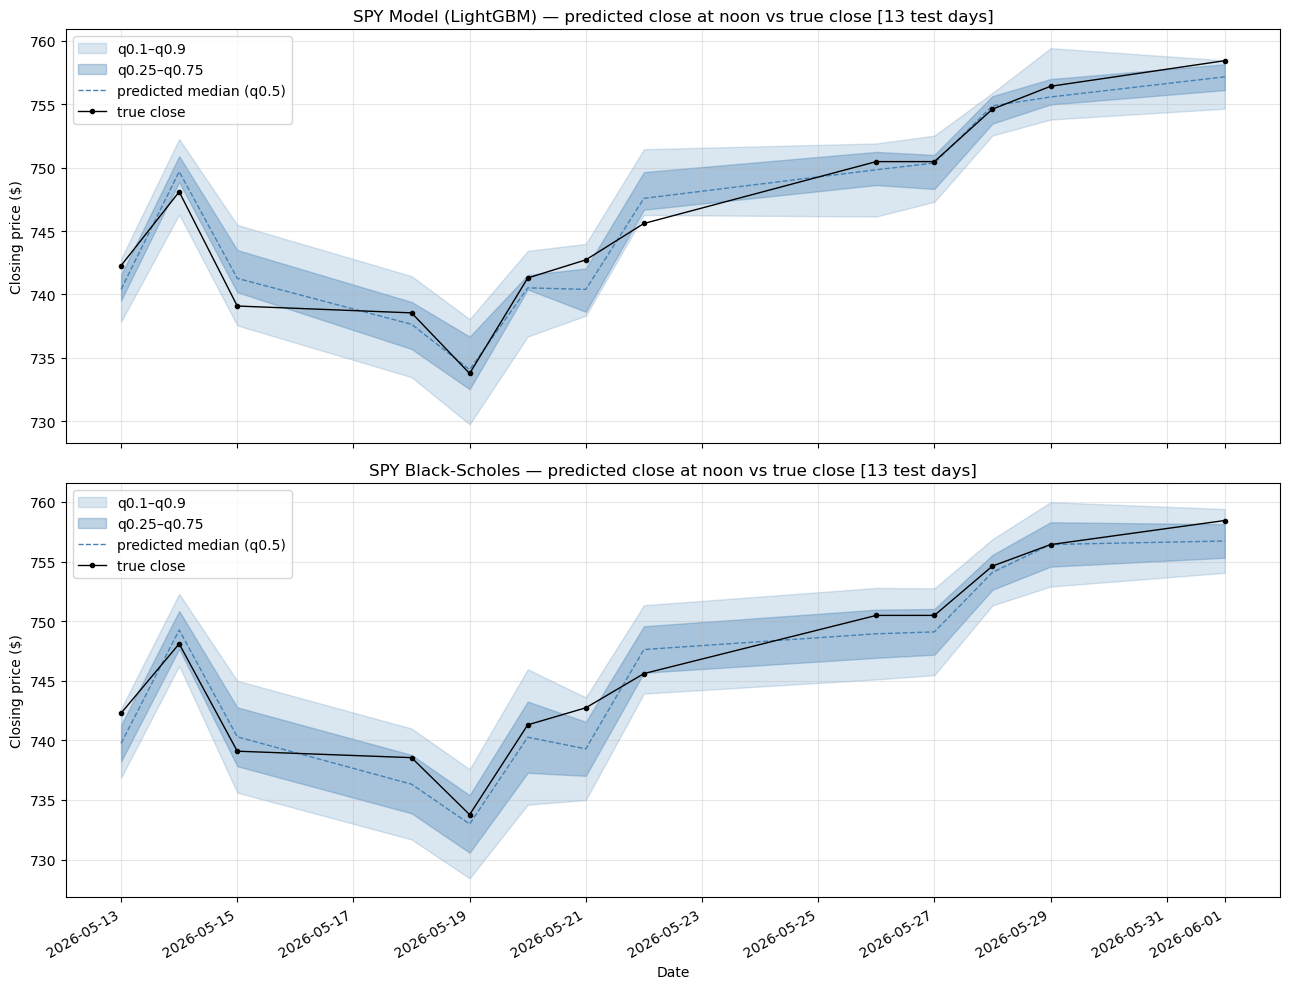

In [15]:
# ── Predicted closing price at noon vs actual close — model & Black-Scholes (test days) ──
# Reconstructs the close from each noon snapshot: close = underlying * exp(log_return),
# where log_return = log_return_norm * norm_factor. Bands show the quantile fan.
import matplotlib.pyplot as plt

_symbol = os.path.basename(cfg.data_path).split(".")[0]
_q = list(cfg.quantiles)
_nq = len(_q)

# Pooled test predictions hold the model's per-row quantiles in log-return space
# (q{ql}_lr = pred_norm * norm_factor). Bring in underlying_price (spot) + ttm to rebuild prices.
# If folds overlap (test_days > stride_days) the same snapshot repeats, so dedupe first.
_src = load_dataset(cfg)[[cfg.group_col, "timestamp", cfg.underlying_col, BS_TTM_COL]]
_p = (results["predictions"]
      .drop_duplicates(subset=[cfg.group_col, "timestamp"])
      .merge(_src, on=[cfg.group_col, "timestamp"], how="left"))
assert _p[cfg.underlying_col].notna().all(), "underlying_price merge produced NaNs"

_spot = _p[cfg.underlying_col].to_numpy()
_nf = _p[cfg.norm_factor_col].to_numpy()

_p["true_close"] = _spot * np.exp(_p["realized_log_return"].to_numpy())
_bs_norm = bs_predict_quantiles(_p, cfg)                      # Black-Scholes, normalized space
for j, ql in enumerate(_q):
    _p[f"model_close_{j}"] = _spot * np.exp(_p[f"q{ql}_lr"].to_numpy())   # model: lr -> price
    _p[f"bs_close_{j}"]    = _spot * np.exp(_bs_norm[:, j] * _nf)         # bs: norm -> lr -> price

# one snapshot per test day: the one nearest noon
_ts = pd.to_datetime(_p["timestamp"])
_p = _p.assign(_dist=(_ts.dt.hour * 60 + _ts.dt.minute - 12 * 60).abs().to_numpy())
_daily = (_p.sort_values([cfg.group_col, "_dist"])
            .groupby(cfg.group_col, as_index=False)
            .head(1)
            .sort_values(cfg.group_col))
_x = pd.to_datetime(_daily[cfg.group_col])
_mid = _nq // 2  # median quantile index (=0.5 for the default symmetric set)


def _fan(ax, prefix, title):
    ax.fill_between(_x, _daily[f"{prefix}_0"], _daily[f"{prefix}_{_nq - 1}"],
                    color="steelblue", alpha=0.20, label=f"q{_q[0]}–q{_q[-1]}")
    if _nq >= 4:
        ax.fill_between(_x, _daily[f"{prefix}_1"], _daily[f"{prefix}_{_nq - 2}"],
                        color="steelblue", alpha=0.35, label=f"q{_q[1]}–q{_q[-2]}")
    ax.plot(_x, _daily[f"{prefix}_{_mid}"], color="steelblue", linestyle="--",
            linewidth=1, label=f"predicted median (q{_q[_mid]})")
    ax.plot(_x, _daily["true_close"], color="black", marker="o", markersize=3,
            linewidth=1, label="true close")
    ax.set_ylabel("Closing price ($)")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)
_fan(axes[0], "model_close", f"{_symbol} Model (LightGBM) — predicted close at noon vs true close [{len(_daily)} test days]")
_fan(axes[1], "bs_close",    f"{_symbol} Black-Scholes — predicted close at noon vs true close [{len(_daily)} test days]")
axes[-1].set_xlabel("Date")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()
